<a href="https://colab.research.google.com/github/RajasukiKaliyaperumal/My_First_project/blob/main/Health_Data_Analysis_And_Calorie_Prediction_Using_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
data_url = "https://www.w3schools.com/python/pandas/data.csv"
full_health_data = pd.read_csv(data_url)
print(full_health_data.head())

   Duration  Pulse  Maxpulse  Calories
0        60    110       130     409.1
1        60    117       145     479.0
2        60    103       135     340.0
3        45    109       175     282.4
4        45    117       148     406.0


In [2]:
print(full_health_data.describe())

         Duration       Pulse    Maxpulse     Calories
count  169.000000  169.000000  169.000000   164.000000
mean    63.846154  107.461538  134.047337   375.790244
std     42.299949   14.510259   16.450434   266.379919
min     15.000000   80.000000  100.000000    50.300000
25%     45.000000  100.000000  124.000000   250.925000
50%     60.000000  105.000000  131.000000   318.600000
75%     60.000000  111.000000  141.000000   387.600000
max    300.000000  159.000000  184.000000  1860.400000


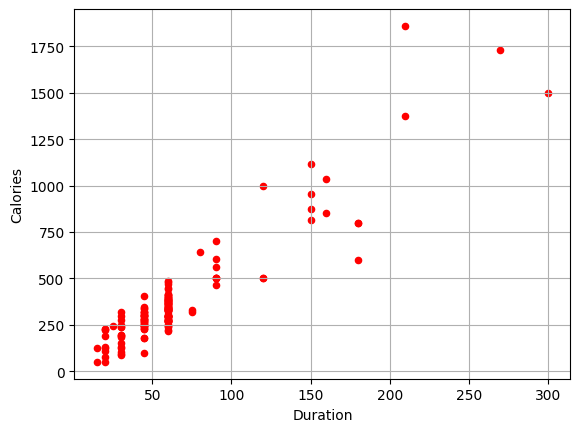

In [3]:
import matplotlib.pyplot as plt
full_health_data.plot(x='Duration', y='Calories', kind='scatter', color='red')
plt.grid(True)
plt.show()

In [17]:
import numpy as np
clean_data = full_health_data.dropna(subset=['Duration', 'Calories'])
x = clean_data['Duration']
y = clean_data['Calories']
slope, intercept = np.polyfit(x,y,1)
new_duration = 85
predicted_calories=(slope * new_duration) + intercept
print(f"Predicted Calories: {predicted_calories:.2f}")

Predicted Calories: 495.30


In [12]:
import statsmodels.api as sm
x = clean_data['Duration']
y = clean_data['Calories']
x = sm.add_constant(x)
model = sm.OLS(y,x).fit()
print(f"R-Squared value: {model.rsquared:.2f}")

R-Squared value: 0.85


In [19]:
import statsmodels.api as sm
x = clean_data[['Duration', 'Pulse']]
y = clean_data['Calories']
x = sm.add_constant(x)
multiple_model = sm.OLS(y,x).fit()
print(f"Multiple Model R-Squared value: {multiple_model.rsquared:.2f}")


Multiple Model R-Squared value: 0.88


In [21]:
new_person = [1,60,110]
predicted_calories_multiple = multiple_model.predict(new_person)
print(f"New Person Predicted Calories: {predicted_calories_multiple[0]:.2f}")

New Person Predicted Calories: 358.82
